## Seepage vs Δh Model Comparison


This notebook compares three models for seepage as a function of the water-level difference 
between estuary and ocean Δh and estuary water level $h_V$ using an effective berm conductance $C$.




### Model-comparison approaches


1. *Pooled fit*: one parameter set fit to all closure events.  
2. *Per-event fits:* parameters estimated separately within each event; results summarized across events.

### Evaluation
- *Information criteria:* *sum* event-level AIC/BIC for per-event fits (equivalently, sum $(-2\log L$) and add penalties).  
- *Goodness of fit:* report $R^2$ and RMSE; provide unweighted and duration-weighted summaries across events.




In [2]:
# ==============================================
# Seepage vs Δh / visitor_h
# Global bounds + Global x_ref + n-weighted grouped medians
# SSE loss
# ==============================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (12.0, 6.0)

# -----------------------------
# Config
# -----------------------------
data_path = Path("../data/processed/pooled_event_df.csv") 
eps = 1e-5
min_n_per_event = 5                       # min days to include an event in grouped fits

# upper bounds for positive offsets 
site_cap_dh  = 1.0   # for Δh-based model
site_cap_vis = 1.0   # for visitor_h-based model

# -----------------------------
# Data loading / preparation
# -----------------------------
df = pd.read_csv(data_path)
df["delta_h"] = pd.to_numeric(df.get("delta_h"), errors="coerce")
df["seepage"] = pd.to_numeric(df.get("seepage"), errors="coerce")
df["visitor_h"] = pd.to_numeric(df.get("visitor_h"), errors="coerce")

# minimal clean
df = df.dropna(subset=["delta_h", "seepage", "visitor_h"]).copy()

# per-event row counts
df["n"] = df.groupby("event")["event"].transform("size").astype("int64")

print(f"Rows: {len(df):,} | Events: {df['event'].nunique():,}")


Rows: 419 | Events: 32


In [3]:

# -----------------------------
# Global x_ref per predictor
# -----------------------------
delta_h_ref  = float(np.nanmedian(df["delta_h"].values))
visitor_h_ref = float(np.nanmedian(df["visitor_h"].values)) 

# -----------------------------
# Global offset bounds (per predictor)
# -----------------------------
def compute_global_offset_bounds(x_series: pd.Series, site_cap: float):
    """
    Lower bound ensures (x + δ) >= ~0 everywhere;
    Upper bound is a site-scale cap informed by data spread.
    """
    x = x_series.to_numpy(float)
    if not np.isfinite(x).any():
        return 0.0, site_cap
    lb = - float(np.nanmin(x)) + 1e-3  # keep base >= 0
    q05, q95 = np.nanquantile(x, [0.05, 0.95])
    spread = float(max(q95 - q05, 1e-6))
    ub = min(0.3*spread, site_cap)
    
    return float(lb), float(ub)

offset_lb_dh,  offset_up_dh  = compute_global_offset_bounds(df["delta_h"], 
                                                            site_cap_dh)
offset_lb_vis, offset_ub_vis = compute_global_offset_bounds(df["visitor_h"], 
                                                            site_cap_vis)


print(f"Global m_Δ (Δh)        = {delta_h_ref:.4f}")
print(f"Global m_V (visitor h) = {visitor_h_ref:.4f}" if np.isfinite(visitor_h_ref) 
          else "Global m_V (visitor h) = N/A")
print(f"Δh  δ bounds:  [{offset_lb_dh:.4f}, {offset_up_dh:.4f}]")
print(f"visitor h δ bounds:  [{offset_lb_vis:.4f}, {offset_ub_vis:.4f}]" )

# -----------------------------
# Helpers
# -----------------------------
def r2_centered(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.mean(y))**2)
    if sst <= 0:
        return np.nan
    sse = np.sum((y - yhat)**2)
    return 1.0 - sse / sst

def weighted_median(values, weights):
    """n-weighted median (by event-duration) across closure events."""
    v = np.asarray(values, float)
    w = np.asarray(weights, float)
    ok = np.isfinite(v) & np.isfinite(w) & (w > 0)
    v, w = v[ok], w[ok]
    if len(v) == 0:
        return np.nan
    order = np.argsort(v)
    v, w = v[order], w[order]
    cw = np.cumsum(w) / np.sum(w)
    return float(v[np.searchsorted(cw, 0.5)])


# Models
def model_linear(C, x):
    return C * x

def model_offset_power_delta_h(C, offset, b, x_dh, delta_h_ref):
    """
    Offset–power model where conductance depends on Δh:

    S = C_Δ · ζ_Δ^{b_Δ} · Δh,   ζ_Δ = (Δh + δ_Δ) / m_Δ

    Parameters map to code variables as:
      C      → C_Δ   (base conductance at ζ_Δ = 1)
      offset → δ_Δ   (vertical offset)
      b      → b_Δ   (power-law exponent)
      delta_h_ref + offset → m_Δ  (median normalization)
    """    
    base = np.maximum(x_dh + offset, eps)
    xref = max(delta_h_ref + offset, eps)
    return C * x_dh * np.power(base / xref, b)

def model_offset_power_visitor_h(C, offset, b, x_dh, x_vis, visitor_h_ref):
    """
    Offset–power model where conductance depends on visitor-center
    water level h_V:

    S = C_V · ζ_V^{b_V} · Δh,   ζ_V = (h_V + δ_V) / m_V

    Parameters map to code variables as:
      C      → C_V   (base conductance at ζ_V = 1)
      offset → δ_V   (vertical offset)
      b      → b_V   (power-law exponent)
      visitor_h_ref + offset → m_V  (median normalization)
    """
    base = np.maximum(x_vis + offset, eps)
    xref = max(visitor_h_ref + offset, eps)
    return C * x_dh * np.power(base / xref, b)

# SSE objectives 
def sse_offset_power_delta_h(theta, x_dh, y, delta_h_ref, lb, ub):
    """
    SSE objective for the Δh-based offset–power model.
    S = C_Δ · ζ_Δ^{b_Δ} · Δh
    """
    C, off, b = theta
    if (C <= 0) or (b < 0) or (off < lb) or (off > ub):
        return 1e99
    yhat = model_offset_power_delta_h(C, off, b, x_dh, delta_h_ref)
    resid = y - yhat
    return float(np.sum(resid * resid))

def sse_offset_power_visitor_h(theta, x_dh, x_vis, y, visitor_h_ref, lb, ub):
    """
    SSE objective for the h_V-based offset–power model.
    S = C_V · ζ_V^{b_V} · Δh
    """
    C, off, b = theta
    if (C <= 0) or (b < 0) or (off < lb) or (off > ub):
        return 1e99
    yhat = model_offset_power_visitor_h(C, off, b, x_dh, x_vis, visitor_h_ref)
    resid = y - yhat
    return float(np.sum(resid * resid))

# -----------------------------
# Pooled fits (SSE)
# -----------------------------
def pooled_linear_delta_h(df_in):    
    """
    Linear seepage model (constant conductance):

        S = C_L · Δh
    """
    x = df_in["delta_h"].to_numpy(float)
    y = df_in["seepage"].to_numpy(float)
    
    # Closed-form through-origin OLS
    denom = max(np.dot(x, x), eps)
    C = float(np.dot(x, y) / denom)
    C = max(C, 1e-12)
    yhat = model_linear(C, x)
    
    return {"C": C, "R2": r2_centered(y, yhat), "n": len(x)}

def pooled_offset_power_delta_h(df_in):
    """
    Fit the pooled offset–power model where conductance depends on Δh:

        S = C_Δ · ζ_Δ^{b_Δ} · Δh,   ζ_Δ = (Δh + δ_Δ) / m_Δ

    using all rows in `df_in` at once (no event grouping).

    Returns dictionary with fitted parameters and diagnostics:
          - "C"      : C_Δ, base conductance at ζ_Δ = 1
          - "offset" : δ_Δ, vertical offset applied to Δh
          - "b"      : b_Δ, exponent controlling sensitivity to Δh
          - "R2"     : centered R² for the pooled fit
          - "n"      : number of points used in the fit
          
    """
    # Predictor and response as 1D float arrays
    x = df_in["delta_h"].to_numpy(float)
    y = df_in["seepage"].to_numpy(float)

    # Initial guess for C: ordinary least-squares slope C ≈ (x·y) / (x·x)
    C0 = float(np.dot(x, y) / max(np.dot(x, x), eps))
    off0 = (offset_lb_dh + offset_up_dh) / 2.0
    # Initial guess for exponent b_Δ
    b0 = 0.5
    # Minimize sum of squared errors for the offset–power model in Δh
    res = minimize(
        sse_offset_power_delta_h,
        x0=[max(C0, 1e-12), off0, b0],
        args=(x, y, delta_h_ref, offset_lb_dh, offset_up_dh),
        bounds=[(1e-12, None), (offset_lb_dh, offset_up_dh), (1e-12, None)],
        method="L-BFGS-B",
    )

    # Extract fitted parameters
    C, off, b = map(float, res.x)

    # Fitted values for diagnostic R²
    yhat = model_offset_power_delta_h(C, off, b, x, delta_h_ref)

    return {
        "C": C,
        "offset": off,
        "b": b,
        "R2": r2_centered(y, yhat),
        "n": len(x),
    }


def pooled_offset_power_visitor_h(df_in):
    """
    Fit the pooled offset–power model where conductance depends on
    visitor-center water level h_V:

        S = C_V · ζ_V^{b_V} · Δh,   ζ_V = (h_V + δ_V) / m_V

    using all rows in `df_in` with non-missing visitor_h.    
    """
    if not df_in["visitor_h"].notna().any():
        return {}
    # Work on subset with valid visitor_h values
    sub = df_in.dropna(subset=["visitor_h"]).copy()

    # Predictors: Δh and h_V, response: seepage S
    x = sub["delta_h"].to_numpy(float)
    xv = sub["visitor_h"].to_numpy(float)
    y = sub["seepage"].to_numpy(float)

    # Initial guess for C: OLS slope using Δh alone
    C0 = float(np.dot(x, y) / max(np.dot(x, x), eps))
    
    # Initial guess for δ_V: mid-point of allowed offset range for visitor_h
    off0 = (offset_lb_vis + offset_ub_vis) / 2.0
    # Initial guess for exponent b_V
    b0 = 0.5
   # Minimize SSE for the offset–power model in h_V 
    res = minimize(
        sse_offset_power_visitor_h,
        x0=[max(C0, 1e-12), off0, b0],
        args=(x, xv, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
        bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
        method="L-BFGS-B",
    )
    C, off, b = map(float, res.x)
    yhat = model_offset_power_visitor_h(C, off, b, x, xv, visitor_h_ref)
    return {"C": C, "offset": off, "b": b, "R2": r2_centered(y, yhat), "n": len(x)}

# -----------------------------
# Optimize parameters by minimizing SSE with bounds:
# - Offset–power: `C ≥ 0`
# - Linear: `C ≥ 0`
# -----------------------------

pooled_lin = pooled_linear_delta_h(df)
pooled_dh  = pooled_offset_power_delta_h(df)
pooled_vis = pooled_offset_power_visitor_h(df)

print("\n=== Pooled (global bounds, global m) ===")
print(f"Linear (Δh):                 C_L={pooled_lin['C']:.2f},   R²={pooled_lin['R2']:.2f}, n={pooled_lin['n']}")
print(f"Offset–Power (Δh):           C_Δ={pooled_dh['C']:.2f}, δ_Δ={pooled_dh['offset']:.2f}, b_Δ={pooled_dh['b']:.2f}, R²={pooled_dh['R2']:.2f}, n={pooled_dh['n']}")
print(f"Offset–Power (h_V):          C_V={pooled_vis['C']:.2f}, δ_V={pooled_vis['offset']:.2f}, b_V={pooled_vis['b']:.2f}, R²={pooled_vis['R2']:.2f}, n={pooled_vis['n']}")

#  


Global m_Δ (Δh)        = 1.6802
Global m_V (visitor h) = 2.6718
Δh  δ bounds:  [-0.7095, 0.4136]
visitor h δ bounds:  [-1.7191, 0.4082]

=== Pooled (global bounds, global m) ===
Linear (Δh):                 C_L=1.07,   R²=0.45, n=419
Offset–Power (Δh):           C_Δ=1.04, δ_Δ=0.27, b_Δ=0.36, R²=0.47, n=419
Offset–Power (h_V):          C_V=1.04, δ_V=-1.72, b_V=0.19, R²=0.48, n=419


In [4]:

# -----------------------------
# Grouped per-event fits (SSE)
# -----------------------------
def fit_grouped_sse(df_in, min_n = min_n_per_event):
    """
    Fit seepage–Δh models separately for each closure event.

    For each event with at least `min_n` points, this function:
      1. Fits a linear model: S = C_L · Δh
      2. Fits an offset–power model on Δh: S = C_Δ · ζ_Δ^{b_Δ} · Δh
      3. Fits an offset–power model on h_V: S = C_V · ζ_V^{b_V} · Δh
    """    
    rows_lin = []
    rows_dh  = []
    rows_vis = []

    # Pre-check for visitor_h availability
    vis_available = df_in["visitor_h"].notna().any()

    for ev, g in df_in.groupby("event"):
        n = int(len(g))
        if n < min_n:
            continue

        x = g["delta_h"].to_numpy(float)
        y = g["seepage"].to_numpy(float)

        # Linear (Δh) — closed form: S = C_L · Δh
        C_lin = float(np.dot(x, y) / max(np.dot(x, x), eps))
        C_lin = max(C_lin, 1e-12)
        yhat_l = model_linear(C_lin, x)
        rows_lin.append({"event": ev, "n": n, "C_lin": C_lin, "R2_lin": r2_centered(y, yhat_l)})


        # Offset–Power (Δh): S = C_Δ · ζ_Δ^{b_Δ} · Δh
        C0 = C_lin
        off0 = (offset_lb_dh + offset_up_dh) / 2.0
        b0 = 0.5
        res_dh = minimize(
            sse_offset_power_delta_h,
            x0=[C0, off0, b0],
            args=(x, y, delta_h_ref, offset_lb_dh, offset_up_dh),
            bounds=[(1e-12, None), (offset_lb_dh, offset_up_dh), (1e-12, None)],
        )
        Cp, offp, bp = map(float, res_dh.x)
        yhat_p = model_offset_power_delta_h(Cp, offp, bp, x, delta_h_ref)
        rows_dh.append({"event": ev, "n": n, "C": Cp, "offset": offp, "b": bp, 
                        "R2": r2_centered(y, yhat_p)})

        # Offset–Power (h_V): S = C_V · ζ_V^{b_V} · Δh
        xv = g["visitor_h"].to_numpy(float)
        if np.isfinite(xv).sum() >= min_n:
            C0v = C_lin
            off0v = (offset_lb_vis + offset_ub_vis) / 2.0
            b0v = 0.5
            res_v = minimize(
                sse_offset_power_visitor_h,
                x0=[C0v, off0v, b0v],
                args=(x, xv, y, visitor_h_ref, offset_lb_vis, offset_ub_vis),
                bounds=[(1e-12, None), (offset_lb_vis, offset_ub_vis), (1e-12, None)],
            )

            Cv, offv, bv = map(float, res_v.x)
            yhat_v = model_offset_power_visitor_h(Cv, offv, bv, x, xv, visitor_h_ref)
            rows_vis.append({"event": ev, "n": n, "C": Cv, "offset": offv, "b": bv, 
                             "R2": r2_centered(y, yhat_v)})

    ev_lin = pd.DataFrame(rows_lin).sort_values("event").reset_index(drop=True)
    ev_dh  = pd.DataFrame(rows_dh).sort_values("event").reset_index(drop=True)
    ev_vis = pd.DataFrame(rows_vis).sort_values("event").reset_index(drop=True) if \
                rows_vis else pd.DataFrame()
    return ev_lin, ev_dh, ev_vis


# -----------------------------
# n-weighted medians of grouped fits
# -----------------------------
def summarize_grouped_weighted_medians(ev_lin, ev_dh, ev_vis):
    """
    Compute n-weighted medians of per-event parameters for each model family.
    """
    out = {}

    if not ev_lin.empty:
        out["Linear (Δh)"] = {
            "C": weighted_median(ev_lin["C_lin"].values, ev_lin["n"].values)
        }

    if not ev_dh.empty:
        out["Offset–Power (Δh)"] = {
            "C":       weighted_median(ev_dh["C"].values, ev_dh["n"].values),
            "offset":  weighted_median(ev_dh["offset"].values, ev_dh["n"].values),
            "b":       weighted_median(ev_dh["b"].values, ev_dh["n"].values),
        }

    if not ev_vis.empty:
        out["Offset–Power (h_V)"] = {
            "C":       weighted_median(ev_vis["C"].values, ev_vis["n"].values),
            "offset":  weighted_median(ev_vis["offset"].values, ev_vis["n"].values),
            "b":       weighted_median(ev_vis["b"].values, ev_vis["n"].values),
        }

    return out

offset_lb_dh = pooled_dh['offset'] - 0.5
offset_up_dh = pooled_dh['offset'] + 0.5
        
offset_lb_vis = pooled_vis['offset'] - 0.5
offset_ub_vis = pooled_vis['offset'] + 0.5


ev_lin, ev_dh, ev_vis = fit_grouped_sse(df, min_n=min_n_per_event)

wmed = summarize_grouped_weighted_medians(ev_lin, ev_dh, ev_vis)

# -----------------------------
# Comparison table (pooled vs grouped w-med)
# -----------------------------
rows = []

# Linear (Δh)
rows.append({
    "Model": "Linear (Δh)",
    "Pooled C": pooled_lin["C"],
    "Grouped C": wmed.get("Linear (Δh)", {}).get("C", np.nan),
})

# Offset–Power (Δh)
rows.append({
    "Model": "Offset–Power (Δh)",
    "Pooled C":      pooled_dh["C"],
    "Grouped C":      wmed.get("Offset–Power (Δh)", {}).get("C", np.nan),
    "Pooled offset": pooled_dh["offset"],
    "Grouped offset": wmed.get("Offset–Power (Δh)", {}).get("offset", np.nan),
    "Pooled b":      pooled_dh["b"],
    "Grouped b":      wmed.get("Offset–Power (Δh)", {}).get("b", np.nan),
})

# Offset–Power (h_V)
rows.append({
    "Model": "Offset–Power (h_V)",
    "Pooled C":      pooled_vis["C"],
    "Grouped C":      wmed.get("Offset–Power (h_V)", {}).get("C", np.nan),
    "Pooled offset": pooled_vis["offset"],
    "Grouped offset": wmed.get("Offset–Power (h_V)", {}).get("offset", np.nan),
    "Pooled b":      pooled_vis["b"],
    "Grouped b":      wmed.get("Offset–Power (h_V)", {}).get("b", np.nan),
})

comp = pd.DataFrame(rows)
num_cols = comp.select_dtypes(include=[float, int]).columns
comp[num_cols] = comp[num_cols].round(3)
comp[num_cols] = comp[num_cols].mask(np.isclose(comp[num_cols], 0.0, atol=5e-4), 0.0)

print("\n=== Comparison (Pooled vs Grouped n-weighted medians) ===")
# print(comp.to_string(index=False))
comp



=== Comparison (Pooled vs Grouped n-weighted medians) ===


,Model,Pooled C,Grouped C,Pooled offset,Grouped offset,Pooled b,Grouped b
0,Linear (Δh),1.069,1.021,NaN,NaN,NaN,NaN
1,Offset–Power (Δh),1.040,0.930,0.265,0.426,0.358,0.265
2,Offset–Power (h_V),1.045,0.937,-1.717,-1.457,0.189,0.142


### Model comparison: Information criteria (AIC/BIC) based on SSE

In [5]:

# --------------------------------
# IC helper: SSE, AIC, BIC
# --------------------------------
def compute_ic(y, yhat, k):
    """
    Compute SSE, AIC, and BIC for a given model fit.
    
    Parameters
    ----------
    y, yhat : array-like
        Observed and predicted values.
    k : int
        Number of free parameters in the model.
        
    Returns
    -------
    dict with keys: n, sse, R2, AIC, BIC
    """
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    ok = np.isfinite(y) & np.isfinite(yhat)
    y, yhat = y[ok], yhat[ok]
    n = len(y)
    if n == 0:
        return {"n": 0, "sse": np.nan, "R2": np.nan, "AIC": np.nan, "BIC": np.nan}
    
    sse = float(np.sum((y - yhat)**2))
    r2  = r2_centered(y, yhat)
    
    sigma2 = sse / n
    aic = n * np.log(sigma2) + 2 * k
    bic = n * np.log(sigma2) + k * np.log(n)
    
    return {"n": n, "sse": sse, "R2": r2, "AIC": aic, "BIC": bic}


# --------------------------------
# Pooled model comparison: AIC/BIC (full dataset)
# --------------------------------
x_all  = df["delta_h"].to_numpy(float)
xv_all = df["visitor_h"].to_numpy(float)
y_all  = df["seepage"].to_numpy(float)

# Predictions from pooled fits
yhat_lin  = model_linear(pooled_lin["C"], x_all)
yhat_dh   = model_offset_power_delta_h(
    pooled_dh["C"], pooled_dh["offset"], pooled_dh["b"],
    x_all, delta_h_ref
)
yhat_vis  = model_offset_power_visitor_h(
    pooled_vis["C"], pooled_vis["offset"], pooled_vis["b"],
    x_all, xv_all, visitor_h_ref
)

stats_lin = compute_ic(y_all, yhat_lin,  k=1)  # C_L
stats_dh  = compute_ic(y_all, yhat_dh,   k=3)  # C_Δ, δ_Δ, b_Δ
stats_vis = compute_ic(y_all, yhat_vis,  k=3)  # C_V, δ_V, b_V

comp_ic = pd.DataFrame([
    {"Model": "Linear (Δh)",              **stats_lin},
    {"Model": "Offset–Power (Δh)",        **stats_dh},
    {"Model": "Offset–Power (h_V)",       **stats_vis},
])

print("\n=== Pooled model comparison (full dataset) ===")
display(comp_ic.round(3).sort_values("AIC"))


best = comp_ic.sort_values("AIC").iloc[0]
comp_ic["dAIC_vs_linear"] = comp_ic["AIC"] - stats_lin["AIC"]
comp_ic["dBIC_vs_linear"] = comp_ic["BIC"] - stats_lin["BIC"]
comp_ic.drop('n', axis = 1).iloc[1:].round(3)



=== Pooled model comparison (full dataset) ===


,Model,n,sse,R2,AIC,BIC
2,Offset–Power (h_V),419,152.646,0.477,-417.085,-404.971
1,Offset–Power (Δh),419,154.711,0.470,-411.456,-399.342
0,Linear (Δh),419,161.039,0.449,-398.657,-394.620


,Model,sse,R2,AIC,BIC,dAIC_vs_linear,dBIC_vs_linear
1,Offset–Power (Δh),154.711,0.470,-411.456,-399.342,-12.798,-4.722
2,Offset–Power (h_V),152.646,0.477,-417.085,-404.971,-18.428,-10.352


### Interpreting AIC and BIC

AIC and BIC are information criteria that score models by trading off goodness of fit against complexity, penalizing extra parameters to guard against overfitting. Both yield a single number per model; only differences between models are meaningful.

**Definitions:**

* **AIC** (Akaike Information Criterion): $\text{AIC} = n \ln(\tfrac{\text{SSE}}{n}) + 2k$
  - Balances goodness of fit (SSE term) against model complexity ($2k$ penalty)
  - Lower AIC indicates better out-of-sample predictive accuracy
  - Lighter penalty on parameters; useful for prediction

* **BIC** (Bayesian Information Criterion): $\text{BIC} = n \ln(\tfrac{\text{SSE}}{n}) + k \ln n$
  - Balances the same fit term but with stronger complexity penalty ($k \ln n$)
  - Lower BIC indicates stronger evidence for the model under Bayesian framework
  - Harsher penalty, especially for large $n$

where $n$ = sample size, SSE = sum of squared residuals, $k$ = number of free parameters.

**Key assumption:** Residuals are independent, identically distributed, and roughly Gaussian with constant variance. Moderate violations are acceptable for comparative purposes.

**Decision rule:** Only differences matter—**absolute AIC/BIC values are meaningless**. Compute ΔAIC = AIC(nonlinear) − AIC(linear):

| ΔAIC or ΔBIC | Interpretation |
|---|---|
| −10 or less | Strong/decisive support for nonlinear model |
| −7 to −4 | Moderate support for nonlinear model |
| −2 to +2 | Negligible difference (models nearly equivalent) |
| +4 to +7 | Moderate support for linear model |
| +10 or more | Strong/decisive support for linear model |

If ΔAIC is small and negative (say −2) but ΔBIC is positive, the nonlinear model adds complexity without compelling gains → prefer linear.

**Results:** 
- Both nonlinear models strongly outperform linear (ΔAIC ≈ −19 to −26, ΔBIC ≈ −11 to −18). The $h_V$ offset–power model has the lowest AIC and BIC and is the *preferred pooled seepage–head model*.


In [6]:

# --------------------------------
# Helper: fit all pooled models on a given dataframe
# --------------------------------
def fit_pooled_all(df_in):
    """
    Fit linear, Δh-power, and h_V-power pooled models on df_in
    and return parameters + R2 + SSE for each.
    """
    # Fit using your existing pooled functions
    plin = pooled_linear_delta_h(df_in)
    pdh  = pooled_offset_power_delta_h(df_in)
    pvis = pooled_offset_power_visitor_h(df_in)

    # Data arrays
    x  = df_in["delta_h"].to_numpy(float)
    xv = df_in["visitor_h"].to_numpy(float)
    y  = df_in["seepage"].to_numpy(float)

    # Predictions
    yhat_lin = model_linear(plin["C"], x)
    yhat_dh  = model_offset_power_delta_h(
        pdh["C"], pdh["offset"], pdh["b"],
        x, delta_h_ref
    )
    yhat_vis = model_offset_power_visitor_h(
        pvis["C"], pvis["offset"], pvis["b"],
        x, xv, visitor_h_ref
    )

    # SSEs
    sse_lin = float(np.sum((y - yhat_lin)**2))
    sse_dh  = float(np.sum((y - yhat_dh)**2))
    sse_vis = float(np.sum((y - yhat_vis)**2))

    out = {
        "lin": {
            "C": plin["C"],
            "R2": r2_centered(y, yhat_lin),
            "SSE": sse_lin,
        },
        "dh": {
            "C": pdh["C"],
            "offset": pdh["offset"],
            "b": pdh["b"],
            "R2": r2_centered(y, yhat_dh),
            "SSE": sse_dh,
        },
        "vis": {
            "C": pvis["C"],
            "offset": pvis["offset"],
            "b": pvis["b"],
            "R2": r2_centered(y, yhat_vis),
            "SSE": sse_vis,
        },
    }
    return out

# --------------------------------
# Bootstrap differences in SSE and R2
# --------------------------------
def bootstrap_pooled_diffs(df, n_boot=500, random_state=0, cluster_by_event=True):
    """
    Bootstrap differences in SSE and R2 between models.

    If cluster_by_event=True, resample whole events (block bootstrap).
    Otherwise, resample individual rows (i.i.d. bootstrap).
    """
    rng = np.random.default_rng(random_state)
    records = []

    if cluster_by_event:
        events = df["event"].unique()
        n_events = len(events)

    for b in range(n_boot):
        # --- resample data ---
        if cluster_by_event:
            boot_events = rng.choice(events, size=n_events, replace=True)
            boot_df = pd.concat(
                [df[df["event"] == ev] for ev in boot_events],
                ignore_index=True,
            )
        else:
            idx = rng.integers(0, len(df), size=int(len(df)*0.8))
            boot_df = df.iloc[idx].reset_index(drop=True)

        # --- fit all pooled models on bootstrap sample ---
        fits = fit_pooled_all(boot_df)

        # --- store differences vs linear ---
        rec = {
            "iter": b,
            "n":    len(boot_df),
            # SSE differences (negative means nonlinear model has smaller SSE)
            "dSSE_dh_vs_lin":  fits["dh"]["SSE"]  - fits["lin"]["SSE"],
            "dSSE_vis_vs_lin": fits["vis"]["SSE"] - fits["lin"]["SSE"],
            # R2 differences (positive means nonlinear model explains more variance)
            "dR2_dh_vs_lin":   fits["dh"]["R2"]   - fits["lin"]["R2"],
            "dR2_vis_vs_lin":  fits["vis"]["R2"]  - fits["lin"]["R2"],
        }
        records.append(rec)

    return pd.DataFrame(records)
# --------------------------------
# Summarize bootstrap results
# --------------------------------
boot = bootstrap_pooled_diffs(df, n_boot=500, random_state=123, cluster_by_event=False)
boot.head()
def summarize_boot_diffs(boot_df):
    stats = {}
    cols = ["dSSE_dh_vs_lin", "dSSE_vis_vs_lin",
            "dR2_dh_vs_lin",  "dR2_vis_vs_lin"]
    for col in cols:
        vals = boot_df[col].to_numpy(float)
        stats[col] = {
            "mean":   float(np.mean(vals)),
            "median": float(np.median(vals)),
            "p2.5":   float(np.quantile(vals, 0.025)),
            "p97.5":  float(np.quantile(vals, 0.975)),
        }
    return pd.DataFrame(stats).T.round(3)

boot_summary = summarize_boot_diffs(boot)
boot_summary
# h_V model best performance; evaluated both bootstrapping and IC



,mean,median,p2.5,p97.5
dSSE_dh_vs_lin,-5.471,-5.011,-12.487,-1.275
dSSE_vis_vs_lin,-7.178,-6.620,-14.191,-2.685
dR2_dh_vs_lin,0.023,0.021,0.006,0.049
dR2_vis_vs_lin,0.030,0.029,0.013,0.055


In [7]:

# --------------------------------
# Bootstrap differences in SSE and R2
# --------------------------------
def bootstrap_pooled_diffs(df, n_boot=500, random_state=0, cluster_by_event=False):
    """
    Bootstrap differences in SSE and R2 between models.

    If cluster_by_event=True, resample whole events (block bootstrap).
    Otherwise, resample individual rows (i.i.d. bootstrap).
    """
    rng = np.random.default_rng(random_state)
    records = []

    if cluster_by_event:
        events = df["event"].unique()
        n_events = len(events)

    for b in range(n_boot):
        # --- resample data ---
        if cluster_by_event:
            boot_events = rng.choice(events, size=n_events, replace=True)
            boot_df = pd.concat(
                [df[df["event"] == ev] for ev in boot_events],
                ignore_index=True,
            )
        else:
            idx = rng.integers(0, len(df), size=int(len(df) * 0.8))
            boot_df = df.iloc[idx].reset_index(drop=True)

        # --- fit all pooled models on bootstrap sample ---
        fits = fit_pooled_all(boot_df)

        # --- store differences ---
        rec = {
            "iter": b,
            "n":    len(boot_df),

            # vs linear (negative dSSE = better than linear; positive dR2 = better than linear)
            "dSSE_dh_vs_lin":   fits["dh"]["SSE"]  - fits["lin"]["SSE"],
            "dSSE_vis_vs_lin":  fits["vis"]["SSE"] - fits["lin"]["SSE"],
            "dR2_dh_vs_lin":    fits["dh"]["R2"]   - fits["lin"]["R2"],
            "dR2_vis_vs_lin":   fits["vis"]["R2"]  - fits["lin"]["R2"],

            # h_V power vs Δh power (negative dSSE = h_V better; positive dR2 = h_V better)
            "dSSE_vis_vs_dh":   fits["vis"]["SSE"] - fits["dh"]["SSE"],
            "dR2_vis_vs_dh":    fits["vis"]["R2"]  - fits["dh"]["R2"],
        }
        records.append(rec)

    return pd.DataFrame(records)



In [8]:
# --------------------------------
# Summarize bootstrap results
# --------------------------------
def summarize_boot_diffs(boot_df):
    """
    Summarize bootstrap differences in SSE and R² between models.
    """
    stats = {}
    cols = [
        "dSSE_dh_vs_lin", "dSSE_vis_vs_lin",  
        "dSSE_vis_vs_dh", 
        "dR2_dh_vs_lin",  "dR2_vis_vs_lin",
        "dR2_vis_vs_dh",
    ]
    for col in cols:
        vals = boot_df[col].to_numpy(float)
        stats[col] = {
            "mean":   float(np.mean(vals)),
            "median": float(np.median(vals)),
            "p2.5":   float(np.quantile(vals, 0.025)),
            "p97.5":  float(np.quantile(vals, 0.975)),
        }
    return pd.DataFrame(stats).T.round(3)

boot = bootstrap_pooled_diffs(df, n_boot=500, random_state=123, cluster_by_event=False)
boot_summary = summarize_boot_diffs(boot)
boot_summary


,mean,median,p2.5,p97.5
dSSE_dh_vs_lin,-5.471,-5.011,-12.487,-1.275
dSSE_vis_vs_lin,-7.178,-6.620,-14.191,-2.685
dSSE_vis_vs_dh,-1.707,-1.657,-3.610,-0.050
dR2_dh_vs_lin,0.023,0.021,0.006,0.049
dR2_vis_vs_lin,0.030,0.029,0.013,0.055
dR2_vis_vs_dh,0.007,0.007,0.000,0.015


Linear: C_L = 1.07.
Δh power: C_Δ = 1.04, δ_Δ = 0.27, b_Δ = 0.36.
h_V power: C_V = 1.04, δ_V = -1.72, b_V = 0.19.


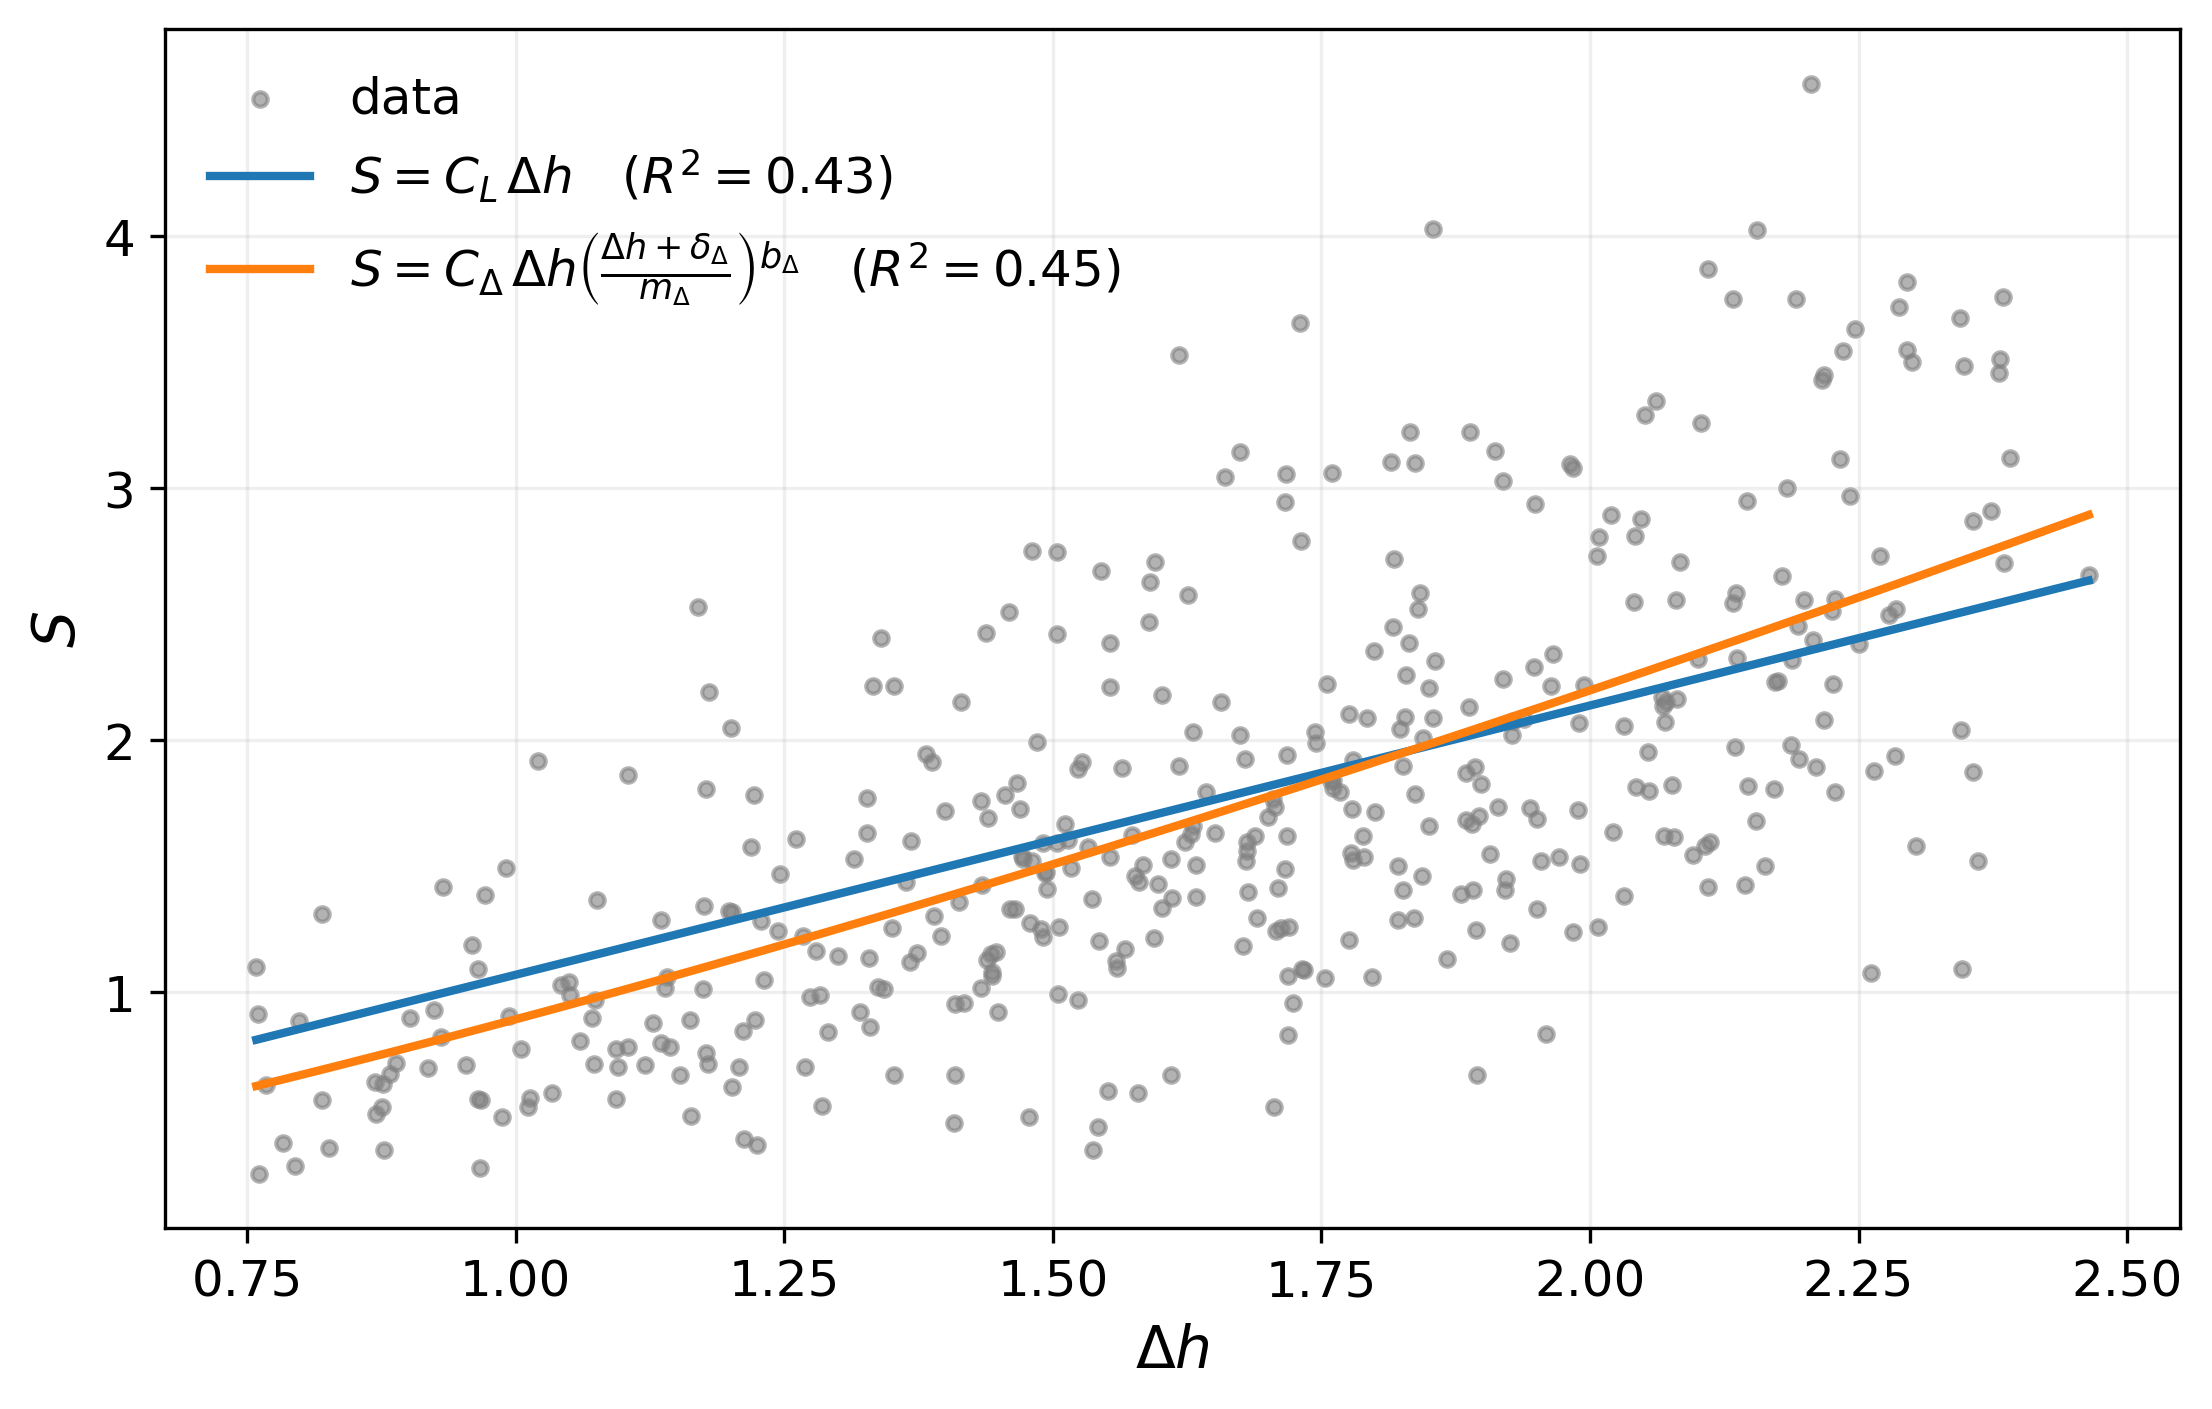

In [14]:

# subset for the panel
df_sub = df.query("delta_h < 2.5 and delta_h > 0.75")

# data arrays
x_all = df_sub["delta_h"].to_numpy(float)
y_all = df_sub["seepage"].to_numpy(float)
h_all = df_sub["visitor_h"].to_numpy(float)

# sort by Δh for clean lines
order = np.argsort(x_all)
xs = x_all[order]
hs = h_all[order]

# pooled params
C_lin   = float(pooled_lin["C"])
C_dh    = float(pooled_dh["C"])
off_dh  = float(pooled_dh["offset"])
b_dh    = float(pooled_dh["b"])

C_vis   = float(pooled_vis["C"])
off_vis = float(pooled_vis["offset"])
b_vis   = float(pooled_vis["b"])

# predictions
ys_lin = model_linear(C_lin, xs)
ys_dh  = model_offset_power_delta_h(C_dh,  off_dh,  b_dh,  xs, delta_h_ref)
ys_vis = model_offset_power_visitor_h(C_vis, off_vis, b_vis, xs, hs, visitor_h_ref)

# optional smoothing of visitor curve for visualization only
try:
    from scipy.signal import savgol_filter
    w = max(7, int(0.02 * len(xs)) | 1)            # odd window ~2% of length
    ys_vis_plot = savgol_filter(ys_vis, w, polyorder=2, mode="interp")
except Exception:
    ys_vis_plot = ys_vis

# compute centered R2 on the same subset
r2_lin = r2_centered(y_all, model_linear(C_lin, x_all))
r2_dh  = r2_centered(y_all, model_offset_power_delta_h(C_dh, off_dh, b_dh, x_all, delta_h_ref))
r2_vis = r2_centered(y_all, model_offset_power_visitor_h(C_vis, off_vis, b_vis, x_all, h_all, visitor_h_ref))

# =============================================
# Legend option A: numeric values inside equations
# =============================================
lab_lin_A = rf"$\hat S = {C_lin:.2f}\,\Delta h \quad (R^2={r2_lin:.2f})$"

lab_dh_A = (
    rf"$\hat S = {C_dh:.2f}\,\Delta h"
    r"\left(\frac{\Delta h+" + f"{off_dh:.2f}" + r"}{" + f"{(delta_h_ref + off_dh):.2f}"
    + r"}\right)^{" + f"{b_dh:.2f}" + rf"}} \quad (R^2={r2_dh:.2f})$"
)

lab_vis_A = (
    rf"$\hat S = {C_vis:.2f}\,\Delta h"
    r"\left(\frac{h_V+" + f"{off_vis:.2f}" + r"}{" + f"{(visitor_h_ref + off_vis):.2f}"
    + r"}\right)^{" + f"{b_vis:.2f}" + rf"}} \quad (R^2={r2_vis:.2f})$"
)

# =============================================
# Legend option B: symbolic equations + parameter values
# =============================================
lab_lin_B = (
    rf"$S = C_L\,\Delta h;\;"
    rf"C_L = {C_lin:.2f},\; R^2={r2_lin:.2f}$"
)

lab_dh_B = (
    r"$S = C_\Delta\,\Delta h"
    r"\left(\frac{\Delta h + \delta_\Delta}{m_\Delta}\right)^{b_{\Delta}};\;"
    + rf"C_\Delta = {C_dh:.2f},\; \delta_\Delta = {off_dh:.2f},\; b_\Delta = {b_dh:.2f},\; R^2={r2_dh:.2f}$"
)

lab_vis_B = (
    r"$S = C_V\,\Delta h"
    r"\left(\frac{h_V + \delta_V}{m_V}\right)^{b_{V}};\;"
    + rf"C_V = {C_vis:.2f},\; \delta_V = {off_vis:.2f},\; b_V = {b_vis:.2f},\; R^2={r2_vis:.2f}$"
)

# =============================================
# Legend option C: symbolic equations + R² in legend; parameters printed as caption
# =============================================
lab_lin_C = rf"$S = C_L\,\Delta h \quad (R^2={r2_lin:.2f})$"

lab_dh_C = (
    r"$S = C_\Delta\,\Delta h"
    r"\left(\frac{\Delta h + \delta_\Delta}{m_\Delta}\right)^{b_{\Delta}}"
    + rf" \quad (R^2={r2_dh:.2f})$"
)

lab_vis_C = (
    r"$S = C_V\,\Delta h"
    r"\left(\frac{h_V + \delta_V}{m_V}\right)^{b_{V}}"
    + rf" \quad (R^2={r2_vis:.2f})$"
)

caption_C = (
    f"Linear: C_L = {C_lin:.2f}.\n"
    f"Δh power: C_Δ = {C_dh:.2f}, δ_Δ = {off_dh:.2f}, b_Δ = {b_dh:.2f}.\n"
    f"h_V power: C_V = {C_vis:.2f}, δ_V = {off_vis:.2f}, b_V = {b_vis:.2f}."
)

# =============================================
# Choose legend style: "A", "B", or "C"
# =============================================
legend_style = "C"

if legend_style == "A":
    lab_lin, lab_dh, lab_vis = lab_lin_A, lab_dh_A, lab_vis_A
elif legend_style == "B":
    lab_lin, lab_dh, lab_vis = lab_lin_B, lab_dh_B, lab_vis_B
else:
    lab_lin, lab_dh, lab_vis = lab_lin_C, lab_dh_C, lab_vis_C

# =============================================
# Font sizes
# =============================================
FONTSIZE_LABEL  = 14
FONTSIZE_TICK   = 12
FONTSIZE_LEGEND = 12
FONTSIZE_CAP    = 10

# plot
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(x_all, y_all, s=12, c="0.5", alpha=0.6, label="data")
ax.plot(xs, ys_lin, lw=2, label=lab_lin)
ax.plot(xs, ys_dh,  lw=2, label=lab_dh)
# ax.plot(xs, ys_vis_plot, lw=2, label=lab_vis)

ax.set_xlabel(r"$\Delta h$", fontsize=FONTSIZE_LABEL)
ax.set_ylabel(r"$S$", fontsize=FONTSIZE_LABEL)
ax.tick_params(labelsize=FONTSIZE_TICK)
ax.legend(frameon=False, loc="upper left", fontsize=FONTSIZE_LEGEND)
ax.grid(alpha=0.2)

if legend_style == "C":
    print(caption_C)

plt.tight_layout()
plt.show()


Linear: C_L = 1.07.
Δh power: C_Δ = 1.04, δ_Δ = 0.27, b_Δ = 0.36.
h_V power: C_V = 1.04, δ_V = -1.72, b_V = 0.19.


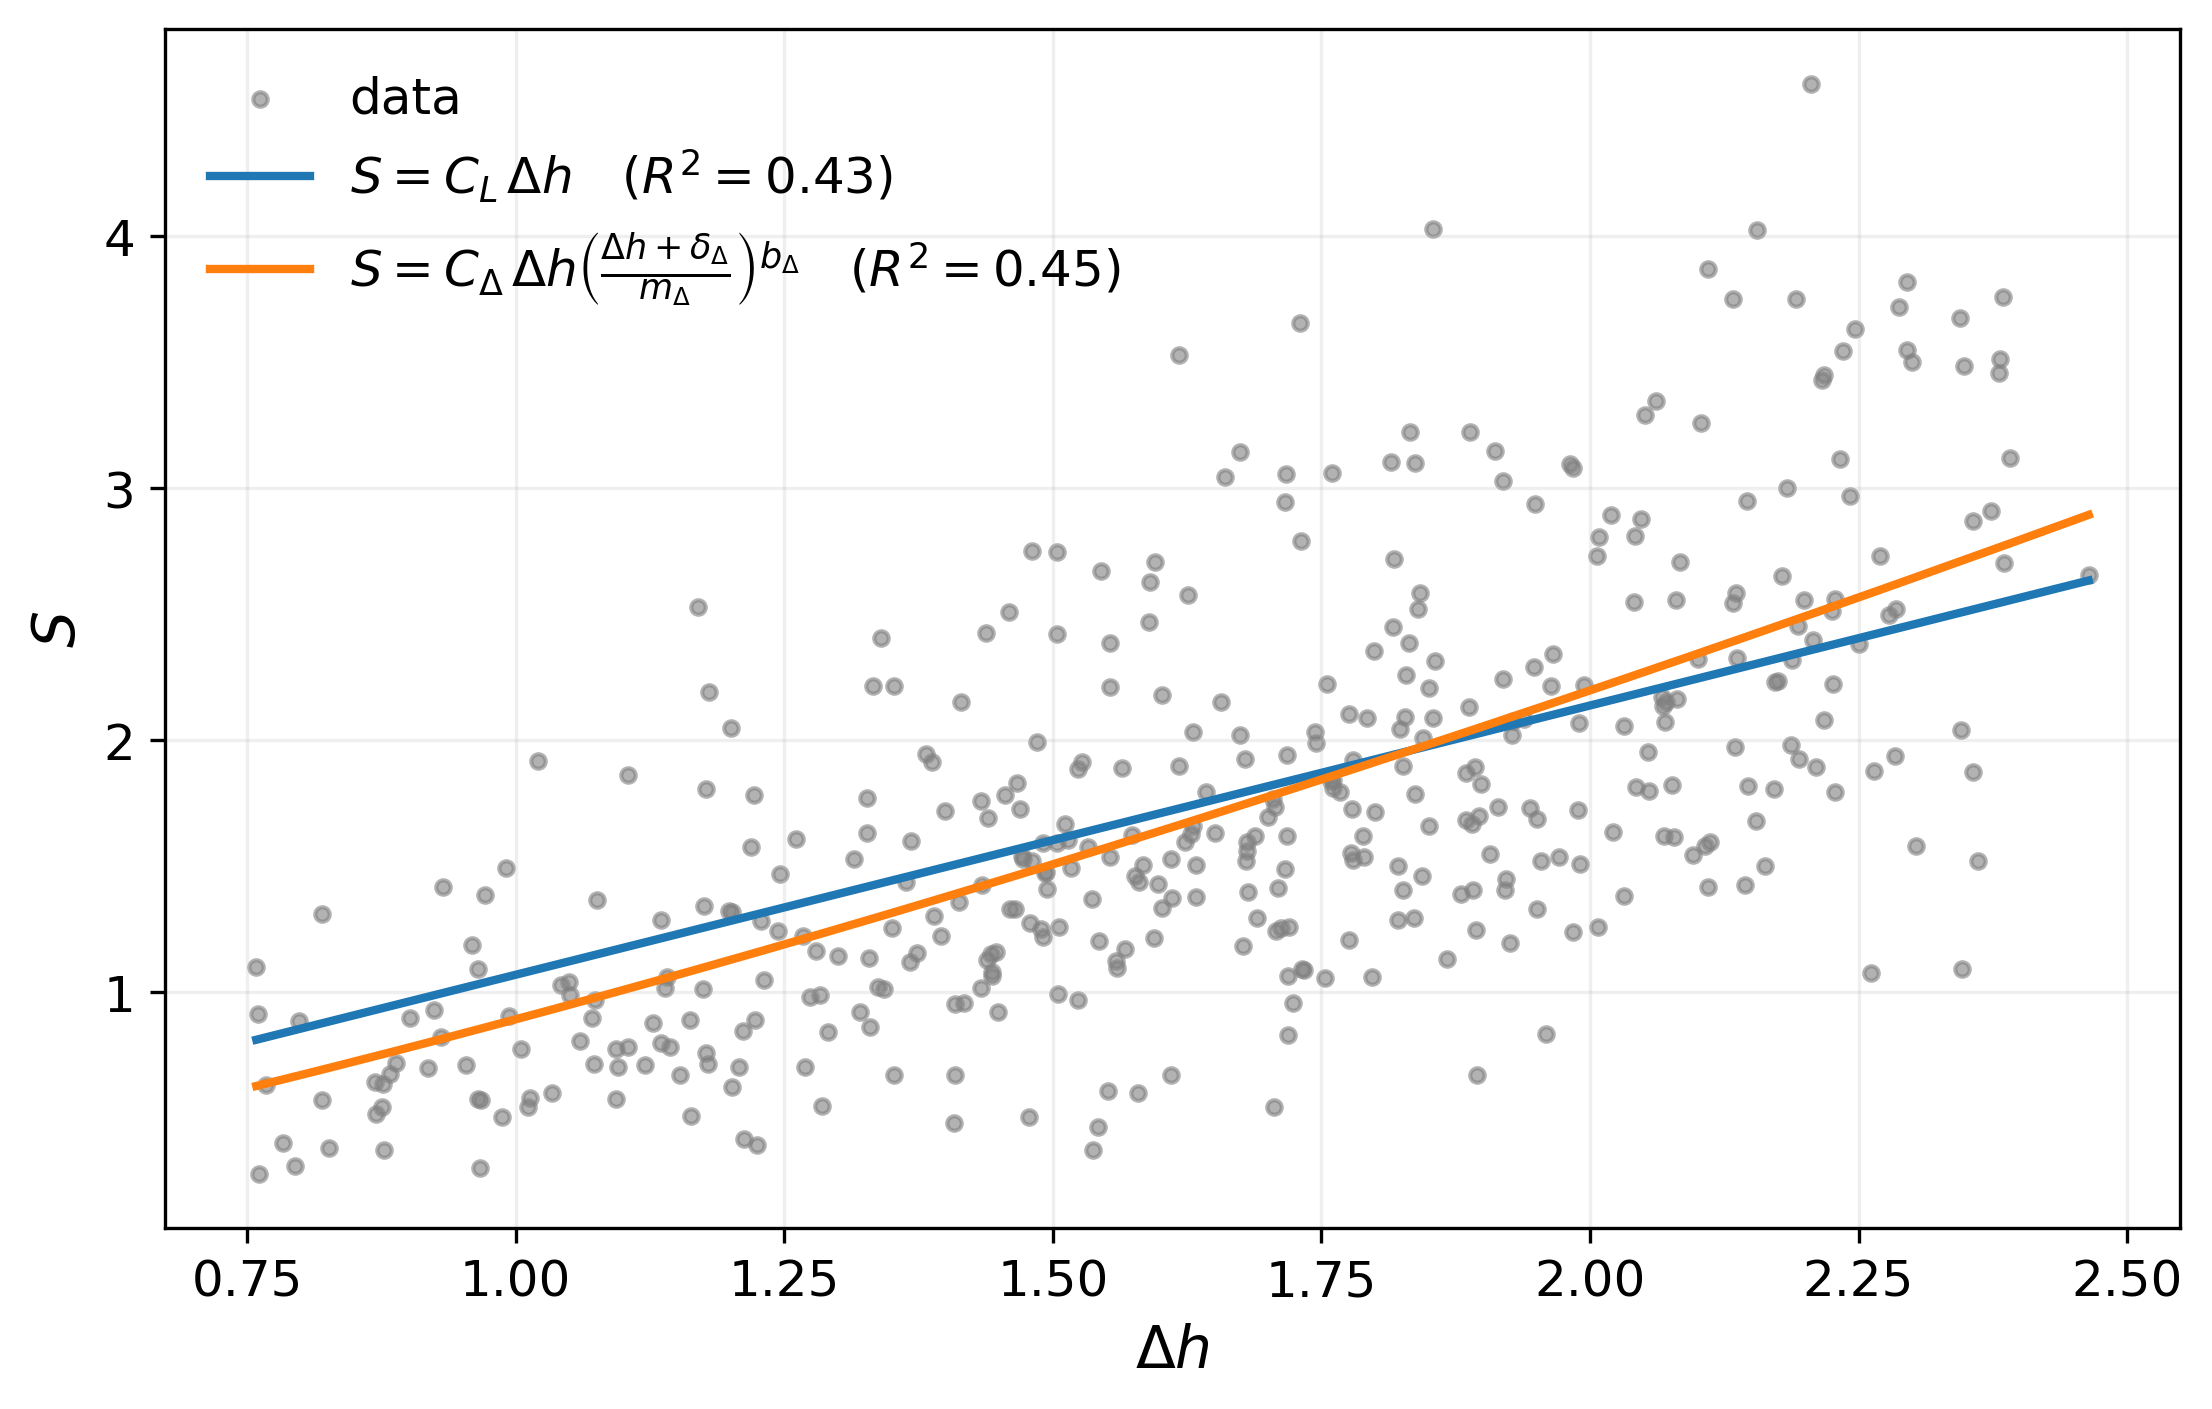

In [15]:
# --- smooth the visitor model line for visualization only ---

try:
    # Savitzky–Golay: smooth but preserves shape better than a boxcar
    from scipy.signal import savgol_filter

    # pick an odd window ~1–3% of series length, clamped
    win = max(7, int(0.2 * len(xs)) | 1)   # ensure odd via bitwise or 1
    win = min(win, len(xs) - (1 - len(xs) % 2))  # keep <= len(xs) and odd
    ys_vis_smooth = savgol_filter(ys_vis, window_length=win, polyorder=2, mode="interp")

except Exception:
    # fallback: centered moving-average
    w = max(7, int(0.02 * len(xs)))
    kernel = np.ones(w, dtype=float) / w
    ys_vis_smooth = np.convolve(ys_vis, kernel, mode="same")

# =============================================
# Legend option A: numeric values inside equations
# =============================================
lab_lin_A = rf"$\hat S = {C_lin:.2f}\,\Delta h \quad (R^2={r2_lin:.2f})$"

lab_dh_A = (
    rf"$\hat S = {C_dh:.2f}\,\Delta h"
    r"\left(\frac{\Delta h+" + f"{off_dh:.2f}" + r"}{" + f"{(delta_h_ref + off_dh):.2f}"
    + r"}\right)^{" + f"{b_dh:.2f}" + rf"}} \quad (R^2={r2_dh:.2f})$"
)

lab_vis_A = (
    rf"$\hat S = {C_vis:.2f}\,\Delta h"
    r"\left(\frac{h_V+" + f"{off_vis:.2f}" + r"}{" + f"{(visitor_h_ref + off_vis):.2f}"
    + r"}\right)^{" + f"{b_vis:.2f}" + rf"}} \quad (R^2={r2_vis:.2f})$"
)

# =============================================
# Legend option B: symbolic equations + parameter values
# =============================================
lab_lin_B = (
    rf"$S = C_L\,\Delta h;\;"
    rf"C_L = {C_lin:.2f},\; R^2={r2_lin:.2f}$"
)

lab_dh_B = (
    r"$S = C_\Delta\,\Delta h"
    r"\left(\frac{\Delta h + \delta_\Delta}{m_\Delta}\right)^{b_{\Delta}};\;"
    + rf"C_\Delta = {C_dh:.2f},\; \delta_\Delta = {off_dh:.2f},\; b_\Delta = {b_dh:.2f},\; R^2={r2_dh:.2f}$"
)

lab_vis_B = (
    r"$S = C_V\,\Delta h"
    r"\left(\frac{h_V + \delta_V}{m_V}\right)^{b_{V}};\;"
    + rf"C_V = {C_vis:.2f},\; \delta_V = {off_vis:.2f},\; b_V = {b_vis:.2f},\; R^2={r2_vis:.2f}$"
)

# =============================================
# Legend option C: symbolic equations + R² in legend; parameters printed as caption
# =============================================
lab_lin_C = rf"$S = C_L\,\Delta h \quad (R^2={r2_lin:.2f})$"

lab_dh_C = (
    r"$S = C_\Delta\,\Delta h"
    r"\left(\frac{\Delta h + \delta_\Delta}{m_\Delta}\right)^{b_{\Delta}}"
    + rf" \quad (R^2={r2_dh:.2f})$"
)

lab_vis_C = (
    r"$S = C_V\,\Delta h"
    r"\left(\frac{h_V + \delta_V}{m_V}\right)^{b_{V}}"
    + rf" \quad (R^2={r2_vis:.2f})$"
)

caption_C = (
    f"Linear: C_L = {C_lin:.2f}.\n"
    f"Δh power: C_Δ = {C_dh:.2f}, δ_Δ = {off_dh:.2f}, b_Δ = {b_dh:.2f}.\n"
    f"h_V power: C_V = {C_vis:.2f}, δ_V = {off_vis:.2f}, b_V = {b_vis:.2f}."
)

# =============================================
# Choose legend style: "A", "B", or "C"
# =============================================
legend_style = "C"

if legend_style == "A":
    lab_lin, lab_dh, lab_vis = lab_lin_A, lab_dh_A, lab_vis_A
elif legend_style == "B":
    lab_lin, lab_dh, lab_vis = lab_lin_B, lab_dh_B, lab_vis_B
else:
    lab_lin, lab_dh, lab_vis = lab_lin_C, lab_dh_C, lab_vis_C

# =============================================
# Font sizes
# =============================================
FONTSIZE_LABEL  = 14
FONTSIZE_TICK   = 12
FONTSIZE_LEGEND = 12
FONTSIZE_CAP    = 10

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(x_all, y_all, s=12, c="0.5", alpha=0.6, label="data")
ax.plot(xs, ys_lin, lw=2, label=lab_lin)
ax.plot(xs, ys_dh,  lw=2, label=lab_dh)
# ax.plot(xs, ys_vis_smooth, lw=2, label=lab_vis)   #  smoothed visitor curve

ax.set_xlabel(r"$\Delta h$", fontsize=FONTSIZE_LABEL)
ax.set_ylabel(r"$S$", fontsize=FONTSIZE_LABEL)
ax.tick_params(labelsize=FONTSIZE_TICK)
ax.legend(frameon=False, loc="upper left", fontsize=FONTSIZE_LEGEND)
ax.grid(alpha=0.2)

if legend_style == "C":
    print(caption_C)

plt.tight_layout()
plt.show()

    

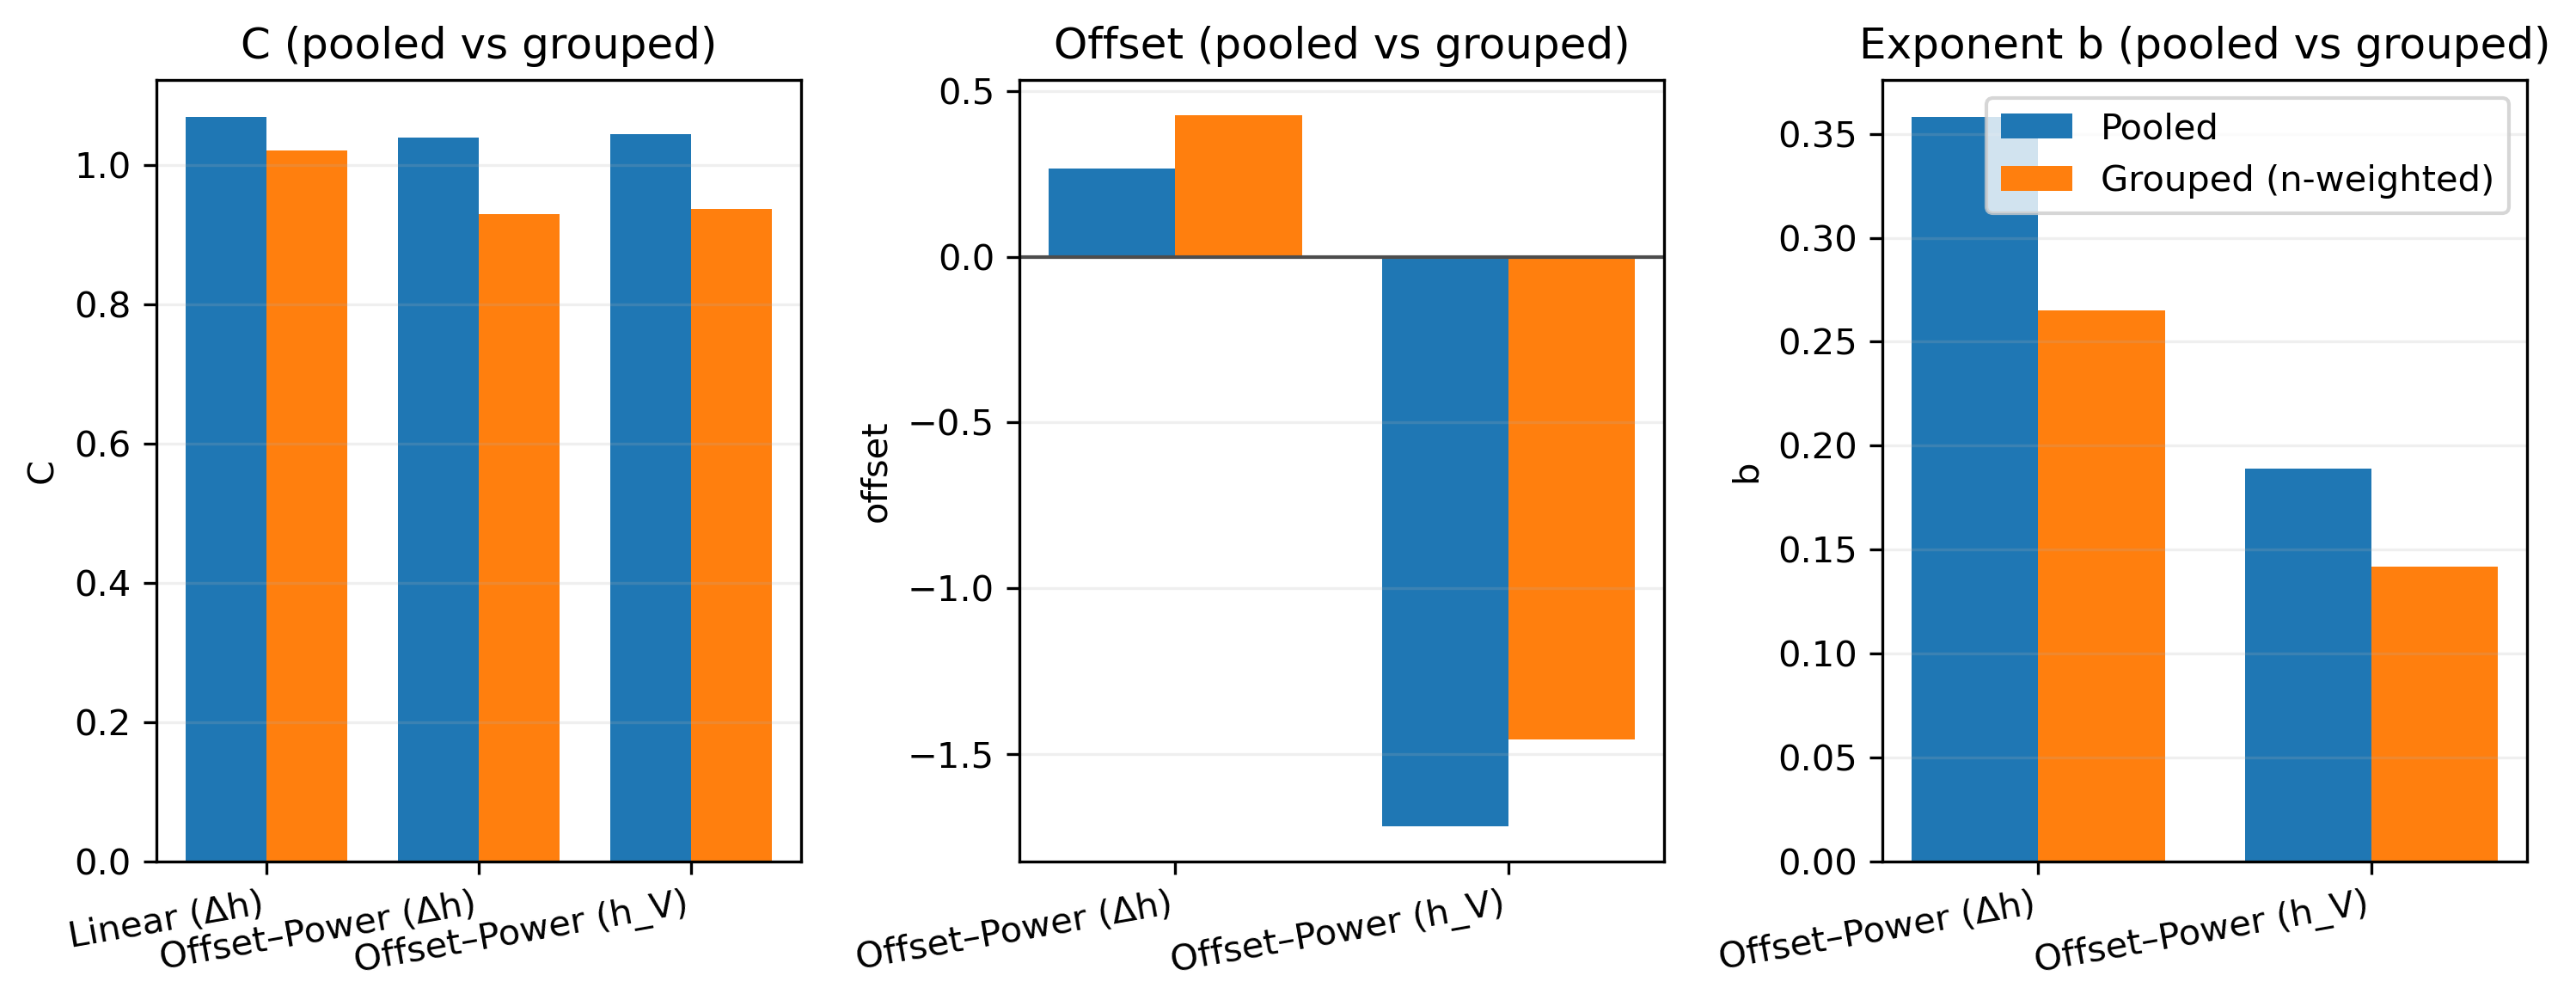

In [16]:
# --- comparison plots: pooled vs grouped (C, offset, b) ---

import numpy as np
import matplotlib.pyplot as plt

# ensure numeric dtype for plotting
for c in ["Pooled C","Grouped C","Pooled offset","Grouped offset","Pooled b","Grouped b"]:
    if c in comp.columns:
        comp[c] = pd.to_numeric(comp[c], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(10, 4))                         
bar_w = 0.38

# 1) C comparison (all models)
ax = axes[0]
idx = np.arange(len(comp))
ax.bar(idx - bar_w/2, comp["Pooled C"],  bar_w, color = 'C0', label="Pooled")
ax.bar(idx + bar_w/2, comp["Grouped C"], bar_w, color = 'C1', label="Grouped (n-weighted)")
ax.set_xticks(idx)
ax.set_xticklabels(comp["Model"], rotation=10, ha="right")
ax.set_ylabel("C")
ax.set_title("C (pooled vs grouped)")
ax.grid(axis="y", alpha=0.2)


# 2) Offset comparison (power models only)
ax = axes[1]
m_off = comp["Pooled offset"].notna() | comp["Grouped offset"].notna()
comp_off = comp[m_off].reset_index(drop=True)
idx_off = np.arange(len(comp_off))
ax.bar(idx_off - bar_w/2, comp_off["Pooled offset"],  bar_w, label="Pooled")
ax.bar(idx_off + bar_w/2, comp_off["Grouped offset"], bar_w, label="Grouped (n-weighted)")
ax.axhline(0, color="0.3", lw=1)
ax.set_xticks(idx_off)
ax.set_xticklabels(comp_off["Model"], rotation=10, ha="right")
ax.set_ylabel("offset")
ax.set_title("Offset (pooled vs grouped)")
ax.grid(axis="y", alpha=0.2)

# 3) b comparison (power models only)
ax = axes[2]
m_b = comp["Pooled b"].notna() | comp["Grouped b"].notna()
comp_b = comp[m_b].reset_index(drop=True)
idx_b = np.arange(len(comp_b))
ax.bar(idx_b - bar_w/2, comp_b["Pooled b"],  bar_w, label="Pooled")
ax.bar(idx_b + bar_w/2, comp_b["Grouped b"], bar_w, label="Grouped (n-weighted)")
ax.set_xticks(idx_b)
ax.set_xticklabels(comp_b["Model"], rotation=10, ha="right")
ax.set_ylabel("b")
ax.set_title("Exponent b (pooled vs grouped)")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
ax.legend(frameon=True)

## Grouped fits (per event)
For each closure event, fit both models, compute $R^2$, SSE, AIC, BIC.  
Aggregate by:
- Weighted centered $R^2$ (weights = per-event samples `n`),
- Summed AIC/BIC across events.
